In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
df=pd.read_csv("gurgaon_properties_cleaned_v1.csv")

In [3]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,pooja room,"245, Sector 85 Gurgaon, Gurgaon, Haryana",21.0,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",This lovely 2 bhk apartment/flat in sector 85 ...,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4.5 out of 5', 'Construction4.5 ou..."
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,"study room,servant room","Sector 113 Gurgaon , Gurgaon, Haryana",3.0,North,0 to 1 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...",La vida by tata housing is one of the most pop...,"['2 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",NaN
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,not available,"Sector 76, Delhi Gurgaon Expressway, Sector 76...",8.0,NaN,undefined,"['S.R.S. Hospital and Critical Care Unit', 'Pe...",Multistorey apartment is available for sale. I...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,study room,"B-505, Sector 43 Gurgaon, Gurgaon, Haryana",5.0,East,10+ Year Old,"['Huda city centre metro station', 'Hanuman Ma...",Residential apartment for sell.Located in sect...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E..."
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,pooja room,"Sector 69 Gurgaon, Gurgaon, Haryana",8.0,East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",A well maintained 3 bhk flat available on sale...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Intercom Facility',...","['Green Area5 out of 5', 'Construction4 out of..."


# 1.areaWithType

In [5]:
df[['price','area','areaWithType']].sample(5)

,price,area,areaWithType
2815,1.05,1550.0,Super Built up area 1550(144 sq.m.)Built Up ar...
2673,0.66,1326.0,Carpet area: 1326 (123.19 sq.m.)
525,1.15,1534.0,Super Built up area 1534(142.51 sq.m.)Carpet a...
1662,1.27,1930.0,Super Built up area 1930(179.3 sq.m.)Built Up ...
1615,1.30,2860.0,Super Built up area 2860(265.7 sq.m.)


# Now we create 3 new columns from the areWithType 
- 1.Super Built up area
- 2.Built up area
- 3.Carpet area

In [8]:
#This function extract super built up area
def get_super_built_up_area(text):
    match=re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [9]:
#This function extract built up area and carpet area
def get_area(text,area_type):
    match=re.search(area_type + r'\s*:\s*(\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [16]:
#This function check that area in sq.m  and convert it in sqft if needed
def convert_to_sqft(text,area_value):
    if area_value==None:
        return None
    match=re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value),text)
    if match:
        sq_m_value=float(match.group(1))
        return sq_m_value*10.7639
    return area_value

In [17]:
#Extract super built up area and convert into sqft
df['super_built_up_area']=df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['super_built_up_area']),axis=1)

In [22]:
#Extract built up area and convert into sqft
df['built_up_area']=df['areaWithType'].apply(lambda x:get_area(x,'Built Up area'))
df['built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['built_up_area']),axis=1)

In [23]:
#Extract Carpet area and convert into sqft
df['carpet_area']=df['areaWithType'].apply(lambda x:get_area(x,'Carpet area'))
df['carpet_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['carpet_area']),axis=1)

In [24]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",This lovely 2 bhk apartment/flat in sector 85 ...,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4.5 out of 5', 'Construction4.5 ou...",1640.0,NaN,NaN
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,North,0 to 1 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...",La vida by tata housing is one of the most pop...,"['2 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",NaN,2690.0,2599.0,2450.0
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,NaN,undefined,"['S.R.S. Hospital and Critical Care Unit', 'Pe...",Multistorey apartment is available for sale. I...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN,NaN,2937.0,1762.0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,East,10+ Year Old,"['Huda city centre metro station', 'Hanuman Ma...",Residential apartment for sell.Located in sect...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",1850.0,NaN,NaN
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",A well maintained 3 bhk flat available on sale...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Intercom Facility',...","['Green Area5 out of 5', 'Construction4 out of...",1578.0,NaN,NaN


In [26]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2194,0.60,flat,900.0,Carpet area: 900 (83.61 sq.m.),NaN,NaN,900.0
768,2.30,flat,1479.0,Built Up area: 1479 (137.4 sq.m.),NaN,1479.0,NaN
3040,0.85,flat,1103.0,Carpet area: 1103 (102.47 sq.m.),NaN,NaN,1103.0
803,1.25,flat,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,1450.0,NaN,1177.0
1568,1.00,flat,2480.0,Built Up area: 2480 (230.4 sq.m.),NaN,2480.0,NaN


In [30]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2205,1.28,flat,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up...,1760.0,1186.0,1130.0
2503,1.45,flat,2150.0,Super Built up area 2150(199.74 sq.m.)Built Up...,2150.0,1797.0,1660.0
2558,4.85,flat,3731.0,Super Built up area 3731(346.62 sq.m.)Built Up...,3731.0,3500.0,3300.0
2819,0.90,flat,1446.0,Super Built up area 1285(119.38 sq.m.)Built Up...,1285.0,1185.0,975.0
1395,1.54,flat,1400.0,Super Built up area 1400(130.06 sq.m.)Built Up...,1400.0,1200.0,1100.0


In [37]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(682, 7)

In [38]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                   9
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
description               0
furnishDetails          981
features                635
rating                  341
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [39]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','pro_nanperty_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [40]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
13,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,NaN,NaN
23,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
24,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,NaN,NaN
25,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,NaN,NaN
27,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,NaN,NaN
...,...,...,...,...,...,...,...
3774,0.50,house,540.0,Plot area 540(50.17 sq.m.),NaN,NaN,NaN
3780,5.85,house,2214.0,Plot area 246(205.69 sq.m.),NaN,NaN,NaN
3789,3.20,house,540.0,Plot area 60(50.17 sq.m.),NaN,NaN,NaN
3795,4.45,house,1265.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [41]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [42]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [43]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [44]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
13,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,402.0,NaN
23,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.0,NaN
24,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,50.0,NaN
25,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,232.0,NaN
27,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,5480.0,NaN


In [45]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [46]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [47]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
13,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,3618.0,NaN
23,1.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.0,NaN
24,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,450.0,NaN
25,6.75,house,2088.0,Plot area 232(193.98 sq.m.),NaN,2088.0,NaN
27,4.35,house,5481.0,Plot area 5480(509.11 sq.m.),NaN,5480.0,NaN


In [48]:
df.update(all_nan_df)

In [49]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                   9
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
description               0
furnishDetails          981
features                635
rating                  341
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [50]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",This lovely 2 bhk apartment/flat in sector 85 ...,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4.5 out of 5', 'Construction4.5 ou...",1640.0,NaN,NaN
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,North,0 to 1 Year Old,"['Dwarka Sector 21', 'Pacific D21 Mall', 'Bajg...",La vida by tata housing is one of the most pop...,"['2 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'...",NaN,2690.0,2599.0,2450.0
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,NaN,undefined,"['S.R.S. Hospital and Critical Care Unit', 'Pe...",Multistorey apartment is available for sale. I...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN,NaN,2937.0,1762.0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,East,10+ Year Old,"['Huda city centre metro station', 'Hanuman Ma...",Residential apartment for sell.Located in sect...,"['1 Wardrobe', '1 Modular Kitchen', 'No AC', '...",NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",1850.0,NaN,NaN
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",A well maintained 3 bhk flat available on sale...,"['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Intercom Facility',...","['Green Area5 out of 5', 'Construction4 out of...",1578.0,NaN,NaN


# 2.additionalRoom

In [51]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
                                                 ... 
store room,study room,servant room                  1
store room,pooja room,servant room,study room       1
study room,store room,pooja room                    1
servant room,store room,study room,pooja room       1
servant room,study room,store room,pooja room       1
Name: count, Length: 65, dtype: int64

In [52]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [53]:
df[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']].sample(5)

,additionalRoom,study room,servant room,store room,pooja room,others
498,study room,1,0,0,0,0
2379,servant room,0,1,0,0,0
3305,not available,0,0,0,0,0
2540,not available,0,0,0,0,0
1732,not available,0,0,0,0,0


In [54]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area4.5 out of 5', 'Construction4.5 ou...",1640.0,NaN,NaN,0,0,0,1,0
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,"['Centrally Air Conditioned', 'Water purifier'...",NaN,2690.0,2599.0,2450.0,1,1,0,0,0
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,NaN,NaN,NaN,2937.0,1762.0,0,0,0,0,0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,NaN,"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E...",1850.0,NaN,NaN,1,0,0,0,0
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,"['Security / Fire Alarm', 'Intercom Facility',...","['Green Area5 out of 5', 'Construction4 out of...",1578.0,NaN,NaN,0,0,0,1,0


# 3.agePossession

In [55]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Aug 2023                 7
Dec 2025                 7
Jun 2024                 7
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Jul 2024                 4
Sep 2023                 4
Aug 2024                 4
Feb 2024                 3
May 2024                 3
Nov 2024                 3
Jan 2025                 3
Jun 2027                 2
Oct 2025                 2
Dec 2026                 2
Jul 2027                 2
Apr 2026                 2
Aug 2025                 2
By 2027                  2
Sep 2025                 2
Jul 2025      

In [56]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [57]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [59]:
df['agePossession']

0       Relatively New
1         New Property
2            Undefined
3         Old Property
4       Relatively New
             ...      
3798      Old Property
3799      New Property
3800         Undefined
3801      New Property
3802    Relatively New
Name: agePossession, Length: 3803, dtype: object

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

# 4.furnishDetails

In [61]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
692,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '5 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
241,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN
2411,"['3 Fan', '1 Exhaust Fan', '1 Geyser', '11 Lig...","['Lift(s)', 'Maintenance Staff', 'Park']"
984,"['5 Wardrobe', '6 Fan', '18 Light', 'No AC', '...","['Private Garden / Terrace', 'High Ceiling Hei..."
3550,"['1 Exhaust Fan', '4 Geyser', '9 Light', '1 Ch...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."


In [63]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [64]:
furnishings_df.shape

(3803, 19)

In [65]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_2936\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [66]:
furnishings_df.sample(5)

,Microwave,Water Purifier,Fridge,TV,Fan,Curtains,Geyser,Bed,Chimney,Washing Machine,AC,Sofa,Light,Exhaust Fan,Stove,Modular Kitchen,Dining Table,Wardrobe
2033,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
623,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2743,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1474,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
981,0,0,0,0,5,8,4,0,1,0,5,0,16,1,1,1,0,5


In [67]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [68]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [69]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

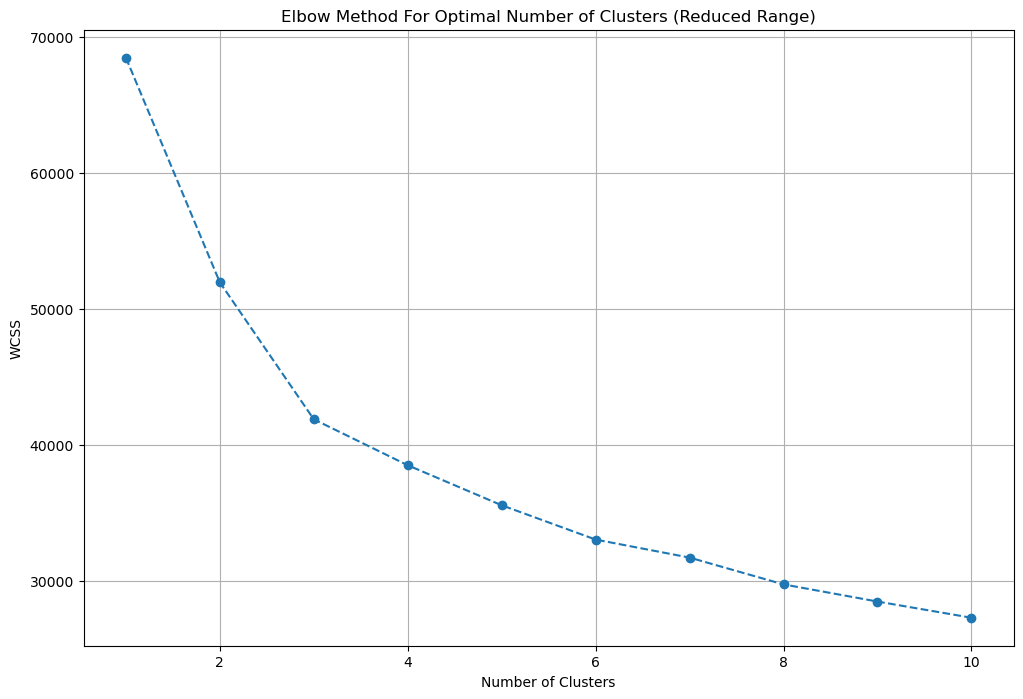

In [70]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [71]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [72]:
df = df.iloc[:,:-18]

In [73]:
df['furnishing_type'] = cluster_assignments

In [74]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1098,NaN,0
3742,NaN,0
2485,"['4 Fan', '1 Exhaust Fan', '4 Light', '1 Curta...",2
2360,"['6 Fan', '6 Light', '4 AC', '1 Modular Kitche...",2
1538,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...",0


# 5.features

In [75]:
df[['society','features']].sample(5)

,society,features
1060,unitech uniworld gardens,"['Feng Shui / Vaastu Compliant', 'Security / F..."
168,sector 15 part 2 rwa,"['Feng Shui / Vaastu Compliant', 'Private Gard..."
2434,breez global heights,"['Feng Shui / Vaastu Compliant', 'Security / F..."
2753,pivotal devaan,"['Water purifier', 'No open drainage around', ..."
445,silverglades the melia,"['Power Back-up', 'Feng Shui / Vaastu Complian..."


In [76]:
df['features'].isnull().sum()

np.int64(635)

In [77]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [78]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [79]:
temp_df = df[df['features'].isnull()]

In [80]:
temp_df.shape

(635, 30)

In [81]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [82]:
df.loc[temp_df.index,'features']=x.values

In [83]:
df['features'].isnull().sum()

np.int64(481)

In [84]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [85]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [86]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2840,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,1,1,0,0
1581,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3666,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
773,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,1,1,0,0
1849,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [87]:
features_binary_df.shape

(3803, 130)

In [88]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

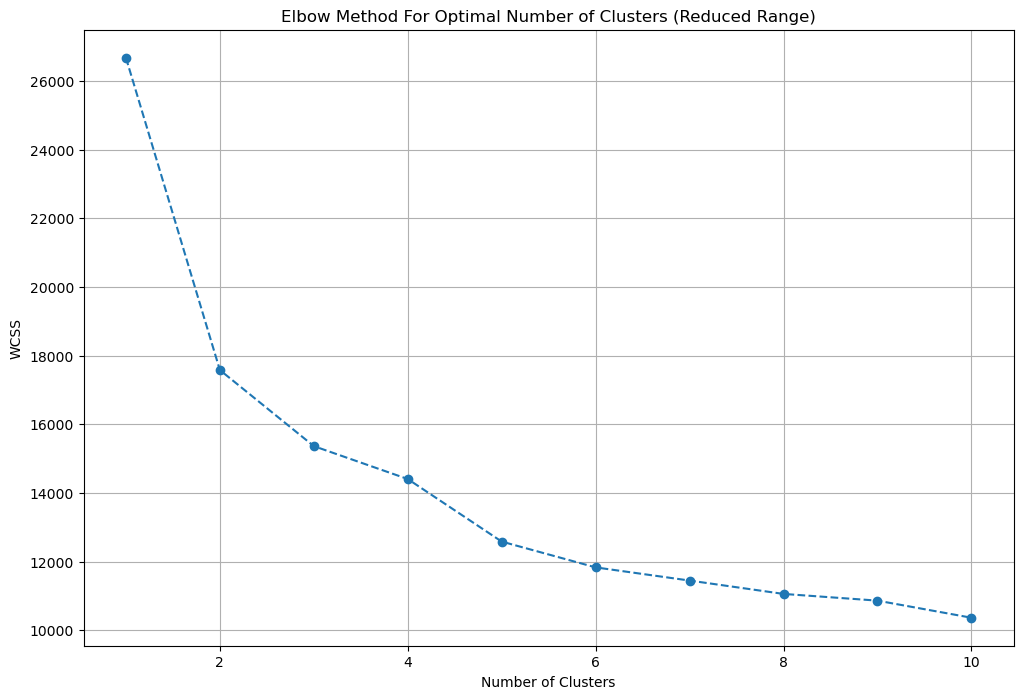

In [89]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [90]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [91]:
df['luxury_score'] = luxury_score

In [92]:
df.head()

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.07,6524.0,1640.0,Super Built up area 1640(152.36 sq.m.),2,2,...,NaN,NaN,0,0,0,1,0,0,"[Power Back-up, Intercom Facility, Lift(s), Sw...",67
1,3 BHK Flat in Sector 113 Gurgaon,flat,la vida by tata housing,sector 113,2.78,11346.0,2450.0,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,...,2599.0,2450.0,1,1,0,0,0,0,"[Centrally Air Conditioned, Water purifier, Se...",174
2,3 BHK Flat in Sector 76 Gurgaon,flat,whiteland the aspen,sector 76,3.50,11917.0,2937.0,Built Up area: 2937 (272.86 sq.m.)Carpet area:...,3,4,...,2937.0,1762.0,0,0,0,0,0,0,[],0
3,3 BHK Flat in Sector 43 Gurgaon,flat,sanskriti apartments,sector 43,2.50,13513.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,2,...,NaN,NaN,1,0,0,0,0,0,[],0
4,3 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,sector 69,1.42,8998.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,...,NaN,NaN,0,0,0,1,0,2,"[Security / Fire Alarm, Intercom Facility, Lif...",94


In [93]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [94]:

df.sample(5)

,property_name,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2691,5 Bedroom House for sale in Sector 14 Gurgaon,house,independent,sector 14,5.50,16975.0,3240.0,Plot area 360(301.01 sq.m.)Built Up area: 355 ...,5,4,...,NaN,355.0,300.0,1,0,0,0,0,0,27
3092,2 BHK Flat in Sector 102 Gurgaon,flat,shapoorji pallonji joyville gurugram,sector 102,1.60,11700.0,1368.0,Built Up area: 1368 (127.09 sq.m.),2,2,...,NaN,1368.0,NaN,0,0,0,0,0,0,0
1105,2 Bedroom House for sale in Sector 7 Gurgaon,house,independent,sector 7,2.00,13889.0,1440.0,Plot area 160(133.78 sq.m.),2,2,...,NaN,1440.0,NaN,0,0,0,0,0,0,22
1023,3 BHK Flat in Sector 36A Gurgaon,flat,krisumi waterfall residences,sector 36a,3.65,14381.0,2538.0,Super Built up area 2538(235.79 sq.m.),3,3,...,2538.0,NaN,NaN,0,0,0,0,0,0,31
45,4 BHK Flat in Sector 103 Gurgaon,flat,indiabulls centrum park,sector 103,2.40,8347.0,2875.0,Super Built up area 2875(267.1 sq.m.)Built Up ...,4,6,...,2875.0,2456.0,2100.0,0,1,0,0,0,0,156


In [95]:
df.shape

(3803, 27)

In [96]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)